# DOT time-domain — Parte 3: modellazione del rumore poissoniano (shot noise)

Questo notebook analizza lo **Step 5** dello script `DOT_Part3_rumore_poisson_TSVD.py`
(aggiunta di rumore poissoniano al vettore delle misure $M = W\,A$) e il suo effetto sulla
ricostruzione TSVD (Step 8–9).

Contenuti:
1. Richiamo compatto del problema diretto (W, A, M) — identico allo script.
2. **Teoria**: dal conteggio TCSPC alla statistica del contrasto $M$ (formule).
3. Implementazione dello script, così com'è.
4. **Verifica Monte Carlo** della varianza e del *bias* dello stimatore.
5. **Problemi concettuali trovati**, quantificati numericamente.
6. Versione corretta: budget fotonico sull'intera TPSF, stimatore quasi non distorto,
   TSVD *pesata* (whitening) al posto della TSVD non pesata.
7. Tabella riassuntiva degli errori.

## 1. Problema diretto (richiamo)

Mezzo semi-infinito, condizioni al contorno a bordo estrapolato (EBC), sorgente isotropa
equivalente a $z_0 = 1/\mu_s'$, immagine a $-z_0-2z_b$, $z_b = 2AD$.
Per un voxel $\mathbf r_v$ con perturbazione $\delta\mu_{a,v}$ (Born I ordine):

$$
\delta\Phi(\mathbf r_d,t) = -\,v\sum_v \delta\mu_{a,v}\,V_{vox}\int_0^t G(\mathbf r_s,\mathbf r_v,t')\,G(\mathbf r_v,\mathbf r_d,t-t')\,dt'
$$

con $G = g(\mathbf r-\mathbf r_s) - g(\mathbf r - \mathbf r_{s,i})$ (4 termini sorgente/immagine). La
convoluzione di due Green di mezzo infinito ha forma chiusa (`deltafluence_inf`).

Integrando su un gate $g=[t_g, t_g+\Delta t_g]$ e normalizzando alla baseline:

$$
M_{dg} = \frac{\int_g \delta\Phi_d\,dt}{\int_g \Phi_{0,d}\,dt} = \sum_v W_{(dg),v}\,\delta\mu_{a,v}
\qquad\Longrightarrow\qquad \mathbf M = W\mathbf A .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, exp

mu_a0, mu_s0, n_idx = 0.01, 1.00, 1.4
D = 1/(3*mu_s0); v = 3e2/n_idx

def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx); z0 = 1/mu_s0; zb = 2*A_coeff*D
r_s0 = np.array([0.0, 0.0, z0]); r_si = np.array([0.0, 0.0, -z0 - 2*zb])

rho_sd = 12.0; angoli = np.arange(0, 360, 45)
det_xy = np.array([[rho_sd*np.cos(np.radians(a)), rho_sd*np.sin(np.radians(a))] for a in angoli])
N_det = det_xy.shape[0]
r_d0 = np.column_stack((det_xy, np.zeros(N_det)))
r_di = np.column_stack((det_xy, np.full(N_det, -2*zb)))

step, x_ext, z_ext = 4.0, 64.0, 32.0
x_coords = np.arange(-x_ext/2 + step/2, x_ext/2, step); y_coords = x_coords.copy()
z_coords = np.arange(step/2, z_ext, step)
X, Y, Z = np.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
r_V = np.column_stack((X.ravel(), Y.ravel(), Z.ravel())); N_vox = r_V.shape[0]; V_vox = step**3

dt = 0.05; t = np.arange(0.1, 10.0, dt)
t_start, gate_width, N_gates = 1.0, 0.20, 12
gates = [(t_start + gate_width*i, t_start + gate_width*(i+1)) for i in range(N_gates)]
gate_indices = [(np.searchsorted(t, g[0]), np.searchsorted(t, g[1])) for g in gates]
print("campioni per gate:", [int(i1-i0) for i0, i1 in gate_indices])

def deltafluence_inf(t, dmu_a, V, r, r1):
    return (-(v**2)/((4*pi*D*v)**(5/2)*t**(3/2))*exp(-mu_a0*v*t)
            * dmu_a*V*(1/r + 1/r1)*exp(-(r+r1)**2/(4*D*v*t)))

def fluence_inf(t, r):
    return (v/(4*pi*D*v*t)**(3/2))*exp(-(r**2/(4*D*v*t)) - mu_a0*v*t)

def phi0_semi(d):
    return fluence_inf(t, np.linalg.norm(r_d0[d]-r_s0)) - fluence_inf(t, np.linalg.norm(r_d0[d]-r_si))

r_sv = np.linalg.norm(r_V - r_s0, axis=1); r_siv = np.linalg.norm(r_V - r_si, axis=1)
W = np.zeros((N_det*N_gates, N_vox)); Phi0_int = np.zeros((N_det, N_gates)); tt = t[None, :]
for d in range(N_det):
    a = np.linalg.norm(r_V - r_d0[d], axis=1)[:, None]; b = np.linalg.norm(r_V - r_di[d], axis=1)[:, None]
    s_, si_ = r_sv[:, None], r_siv[:, None]
    dphi = (deltafluence_inf(tt, 1, V_vox, s_, a) - deltafluence_inf(tt, 1, V_vox, s_, b)
            - deltafluence_inf(tt, 1, V_vox, si_, a) + deltafluence_inf(tt, 1, V_vox, si_, b))
    p0 = phi0_semi(d)
    for g, (i0, i1) in enumerate(gate_indices):
        Phi0_int[d, g] = p0[i0:i1].sum()*dt
        W[d*N_gates + g] = dphi[:, i0:i1].sum(1)*dt / Phi0_int[d, g]

dmu_a, xp, yp, zp = 0.01, 14.0, 10.0, 18.0
L_incl = V_vox**(1/3)
mask = (np.abs(X-xp) <= L_incl/2) & (np.abs(Y-yp) <= L_incl/2) & (np.abs(Z-zp) <= L_incl/2)
A = (mask*dmu_a).ravel()
M_ideal = (W @ A).reshape(N_det, N_gates)
print("W:", W.shape, "| voxel perturbati:", int(mask.sum()))
print("M_ideal (D1):", np.round(M_ideal[0], 5))

campioni per gate: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


W: (96, 2048) | voxel perturbati: 1
M_ideal (D1): [-0.0002  -0.00051 -0.00103 -0.00172 -0.00255 -0.00348 -0.00447 -0.00549
 -0.00651 -0.00751 -0.00848 -0.00941]


## 2. Teoria: dal conteggio di fotoni al rumore sul contrasto

### 2.1 Il dato grezzo è un conteggio
In un sistema TCSPC il dato grezzo è l'istogramma dei tempi di arrivo. Il numero di fotoni
nel gate $g$ del rivelatore $d$ è una variabile di Poisson:

$$
N_{dg}\sim\mathcal P(\lambda_{dg}),\qquad P(N=k)=\frac{\lambda^k e^{-\lambda}}{k!},\qquad
\mathbb E[N]=\mathrm{Var}[N]=\lambda,\qquad \mathrm{SNR}=\frac{\lambda}{\sqrt\lambda}=\sqrt\lambda .
$$

Il valore atteso è proporzionale all'integrale della fluenza nel gate (a meno di un fattore
strumentale $\eta$ = potenza × efficienza × tempo di acquisizione × area):

$$
\lambda^{(0)}_{dg} = \eta_d\int_g \Phi_{0,d}(t)\,dt ,\qquad
\lambda^{(p)}_{dg} = \eta_d\int_g \big(\Phi_{0,d}+\delta\Phi_d\big)dt = \lambda^{(0)}_{dg}\,(1+M_{dg}).
$$

Lo script fissa $\eta_d$ imponendo un budget $N_{tot}$ di conteggi per rivelatore:
$\lambda^{(0)}_{dg} = N_{tot}\,\Phi^{int}_{0,dg}/\sum_{g'}\Phi^{int}_{0,dg'}$.
**Attenzione**: la somma è sui soli 12 gate, non sull'intera TPSF (vedi §5.1).

### 2.2 Stimatore del contrasto
Da due acquisizioni indipendenti (baseline $N^{(0)}$ e perturbata $N^{(p)}$):

$$
\hat M_{dg} = \frac{N^{(p)}_{dg}-N^{(0)}_{dg}}{N^{(0)}_{dg}} = \frac{N^{(p)}_{dg}}{N^{(0)}_{dg}}-1 .
$$

### 2.3 Varianza (metodo delta)
Per $f(x,y)=x/y$ con $x,y$ indipendenti:
$\mathrm{Var}[f]\approx f^2\left(\frac{\mathrm{Var}\,x}{x^2}+\frac{\mathrm{Var}\,y}{y^2}\right)$. Con la
statistica di Poisson ($\mathrm{Var}\,x=\lambda^{(p)}$, $\mathrm{Var}\,y=\lambda^{(0)}$):

$$
\boxed{\;\sigma^2_{M,dg}\approx (1+M)^2\left(\frac1{\lambda^{(0)}(1+M)}+\frac1{\lambda^{(0)}}\right)
=\frac{(1+M)(2+M)}{\lambda^{(0)}_{dg}}\;\approx\;\frac{2}{\lambda^{(0)}_{dg}}\;}
$$

Il fattore **2** viene dal fatto che *anche la baseline è misurata* (rumorosa). Se la
baseline fosse calcolata dal modello (senza rumore) si avrebbe $\sigma^2_M\approx(1+M)/\lambda^{(0)}$.

SNR del singolo dato:
$$\mathrm{SNR}_{dg}=\frac{|M_{dg}|}{\sigma_{M,dg}}\approx |M_{dg}|\sqrt{\lambda^{(0)}_{dg}/2}.$$

### 2.4 Bias dello stimatore rapporto
$\mathbb E[1/N^{(0)}]\neq 1/\lambda^{(0)}$. Sviluppando al II ordine,
$\mathbb E[1/N]\approx\frac1\lambda\left(1+\frac1\lambda\right)$, quindi

$$
\mathbb E[\hat M]\approx (1+M)\left(1+\frac1{\lambda^{(0)}}\right)-1 \;\Rightarrow\; \mathrm{bias}\approx\frac{1+M}{\lambda^{(0)}} .
$$

Poiché $|M|$ è dell'ordine di $10^{-3}$–$10^{-2}$, il bias diventa confrontabile con il
segnale quando $\lambda^{(0)}\lesssim 1/|M|$, cioè proprio nei gate tardivi.
Uno stimatore quasi non distorto (e che non divide mai per zero) è

$$
\tilde M = \frac{N^{(p)}}{N^{(0)}+1}-1,\qquad \mathbb E\!\left[\frac{1}{N^{(0)}+1}\right]=\frac{1-e^{-\lambda^{(0)}}}{\lambda^{(0)}}
\;\Rightarrow\; \mathbb E[\tilde M]=(1+M)(1-e^{-\lambda^{(0)}})-1 .
$$

### 2.5 Conseguenza per l'inversione
Il rumore su $\mathbf M$ è a media nulla (circa) ma **eteroschedastico**:
$\Sigma=\mathrm{diag}(\sigma^2_{M,dg})$ con $\sigma$ che varia di più di un ordine di grandezza fra
il primo e l'ultimo gate. La soluzione a massima verosimiglianza (gaussiana, $\lambda$ grande) è
un minimo quadrato **pesato**:

$$
\hat{\mathbf A}=\arg\min_{\mathbf A}\big\|\Sigma^{-1/2}(W\mathbf A-\mathbf M)\big\|^2
\quad\Longrightarrow\quad \tilde W=\Sigma^{-1/2}W,\;\;\tilde{\mathbf M}=\Sigma^{-1/2}\mathbf M,
$$

e la TSVD va applicata a $\tilde W$ (whitening). La TSVD non pesata dello script tratta tutte le
righe con lo stesso peso.

## 3. Implementazione dello script (Step 5, invariata)

Conteggi baseline per gate (D1): [524823 241231 115534  57181  29066  15105   7996   4300   2344   1293
    721    405]


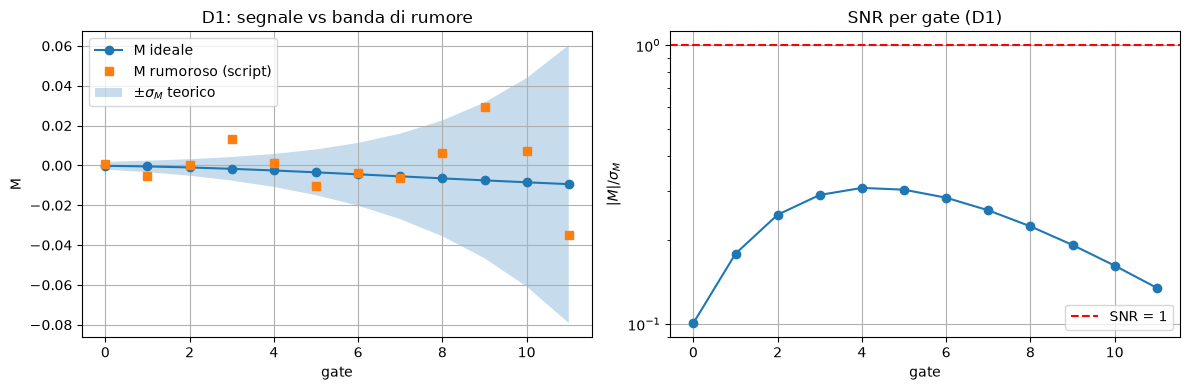

SNR per gate D1: [0.1  0.18 0.25 0.29 0.31 0.3  0.28 0.26 0.22 0.19 0.16 0.13]
SNR complessivo sqrt(sum SNR^2) su 96 misure: 1.54


In [2]:
np.random.seed(42)
N_tot = 1e6
N0_ideal = N_tot * Phi0_int / Phi0_int.sum(axis=1, keepdims=True)
Npert_ideal = N0_ideal * (1 + M_ideal)
N0_noisy = np.random.poisson(N0_ideal)
Npert_noisy = np.random.poisson(np.clip(Npert_ideal, 0, None))
with np.errstate(divide='ignore', invalid='ignore'):
    M_noisy = np.where(N0_noisy > 0, (Npert_noisy - N0_noisy) / N0_noisy, np.nan)

print(f"Conteggi baseline per gate (D1): {np.round(N0_ideal[0]).astype(int)}")

sigma_M = np.sqrt((1 + M_ideal)*(2 + M_ideal)/N0_ideal)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
g_idx = np.arange(N_gates)
ax[0].plot(g_idx, M_ideal[0], 'o-', label='M ideale')
ax[0].plot(g_idx, M_noisy[0], 's', label='M rumoroso (script)')
ax[0].fill_between(g_idx, M_ideal[0]-sigma_M[0], M_ideal[0]+sigma_M[0], alpha=.25, label=r'$\pm\sigma_M$ teorico')
ax[0].set(xlabel='gate', ylabel='M', title='D1: segnale vs banda di rumore'); ax[0].legend(); ax[0].grid()
ax[1].semilogy(g_idx, np.abs(M_ideal[0])/sigma_M[0], 'o-')
ax[1].axhline(1, color='r', ls='--', label='SNR = 1')
ax[1].set(xlabel='gate', ylabel=r'$|M|/\sigma_M$', title='SNR per gate (D1)'); ax[1].legend(); ax[1].grid()
plt.tight_layout(); plt.show()
print("SNR per gate D1:", np.round(np.abs(M_ideal[0])/sigma_M[0], 2))
print("SNR complessivo sqrt(sum SNR^2) su 96 misure:", round(float(np.sqrt(((M_ideal/sigma_M)**2).sum())), 2))

## 4. Verifica Monte Carlo di varianza e bias

Si ripete l'acquisizione $R$ volte sul gate più tardivo (pochi conteggi) e su uno precoce,
confrontando media e deviazione standard empiriche con le formule del §2.

In [3]:
rng = np.random.default_rng(0); R = 200_000
for g in [0, 11]:
    lam0, M = N0_ideal[0, g], M_ideal[0, g]
    n0 = rng.poisson(lam0, R); npert = rng.poisson(lam0*(1+M), R)
    M_hat = (npert - n0)/n0                  # stimatore dello script
    M_til = npert/(n0 + 1) - 1               # stimatore corretto
    print(f"gate {g:2d}: lambda0={lam0:9.1f}  M vero={M:+.5f}")
    print(f"   std empirica = {M_hat.std():.5f}   teorica sqrt((1+M)(2+M)/lambda0) = {np.sqrt((1+M)*(2+M)/lam0):.5f}")
    print(f"   bias (N_p-N_0)/N_0   = {M_hat.mean()-M:+.5f}  (teorico (1+M)/lambda0 = {(1+M)/lam0:+.5f}, "
          f"err. MC ±{M_hat.std()/np.sqrt(R):.5f})")
    print(f"   bias N_p/(N_0+1)-1   = {M_til.mean()-M:+.5f}")

gate  0: lambda0= 524822.9  M vero=-0.00020
   std empirica = 0.00195   teorica sqrt((1+M)(2+M)/lambda0) = 0.00195
   bias (N_p-N_0)/N_0   = +0.00000  (teorico (1+M)/lambda0 = +0.00000, err. MC ±0.00000)
   bias N_p/(N_0+1)-1   = +0.00000
gate 11: lambda0=    405.3  M vero=-0.00941
   std empirica = 0.07019   teorica sqrt((1+M)(2+M)/lambda0) = 0.06975
   bias (N_p-N_0)/N_0   = +0.00248  (teorico (1+M)/lambda0 = +0.00244, err. MC ±0.00016)
   bias N_p/(N_0+1)-1   = +0.00003


La varianza teorica è confermata; il bias $\approx 1/\lambda^{(0)}$ è reale e, nel gate 11,
vale circa il **25 % del segnale**. Con lo stimatore $N^{(p)}/(N^{(0)}+1)-1$ il bias scompare
(entro l'errore Monte Carlo).

## 5. Problemi concettuali trovati

### 5.1 I gate non contengono il picco della TPSF — il budget $N_{tot}$ è mal interpretato
Il commento dello script dice *"più conteggi dove la TPSF è alta (vicino al picco)"*, ma con
$\rho=12$ mm e $\mu_s'=1$ mm$^{-1}$ il picco della TPSF è a pochi decimi di ns, **prima** del
primo gate (1.0 ns). La normalizzazione `Phi0_int / Phi0_int.sum(axis=1)` distribuisce tutti i
$10^6$ conteggi dentro la finestra 1.0–3.4 ns, che però contiene solo una piccola frazione
dell'intera curva. Il commento *"1e4–1e6 conteggi totali per curva TPSF"* non corrisponde quindi
a ciò che il codice fa: $N_{tot}=10^6$ nei gate equivale a circa $4\cdot10^7$ conteggi sull'intera TPSF.

Picco TPSF a t = 0.20 ns (primo gate a 1.0 ns)
Frazione della TPSF (0.1-10 ns) contenuta nei 12 gate: 2.52 %
N_tot=1e6 nei gate  <=>  4.0e+07 conteggi sull'intera TPSF
Conteggi per gate se 1e6 = intera TPSF: [13215  6074  2909  1440   732   380   201   108    59    33    18    10]


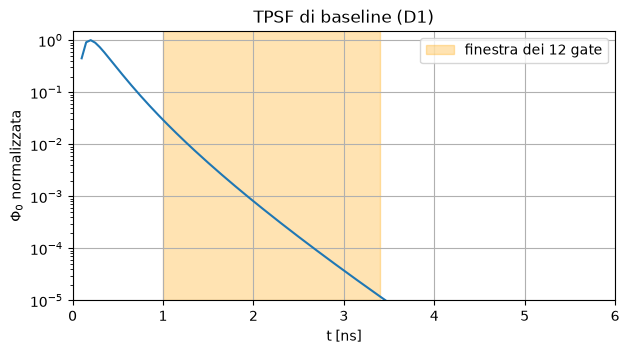

In [4]:
p0 = phi0_semi(0)
i_a, i_b = gate_indices[0][0], gate_indices[-1][1]
frac = p0[i_a:i_b].sum()/p0.sum()
print(f"Picco TPSF a t = {t[np.argmax(p0)]:.2f} ns (primo gate a {gates[0][0]} ns)")
print(f"Frazione della TPSF (0.1-10 ns) contenuta nei 12 gate: {100*frac:.2f} %")
print(f"N_tot=1e6 nei gate  <=>  {1e6/frac:.1e} conteggi sull'intera TPSF")
N0_real = 1e6 * Phi0_int[0] / (p0.sum()*dt)
print("Conteggi per gate se 1e6 = intera TPSF:", np.round(N0_real).astype(int))

plt.figure(figsize=(7, 3.5))
plt.semilogy(t, p0/p0.max()); plt.axvspan(gates[0][0], gates[-1][1], color='orange', alpha=.3, label='finestra dei 12 gate')
plt.xlabel('t [ns]'); plt.ylabel(r'$\Phi_0$ normalizzata'); plt.xlim(0, 6); plt.ylim(1e-5, 1.5)
plt.legend(); plt.grid(); plt.title('TPSF di baseline (D1)'); plt.show()

### 5.2 SNR per gate < 1: il dato è dominato dal rumore
Con i parametri dello script ($\delta\mu_a=0.01$ mm$^{-1}$, un voxel da 64 mm$^3$ a 18 mm di
profondità) $|M|\sim10^{-4}$–$10^{-2}$ mentre $\sigma_M\sim2\cdot10^{-3}$–$7\cdot10^{-2}$: lo SNR
di **ogni** misura è ~0.1–0.3 e lo SNR complessivo sulle 96 misure è ~1.5 (vedi §3). Una
ricostruzione 3D è quindi fuori portata a questo livello di rumore: il minimo "a $k$ finito"
della curva di errore dello Step 8 si troverà a $k$ molto piccolo, e non va interpretato come
una ricostruzione riuscita.

### 5.3 Rumore eteroschedastico e TSVD non pesata
$\sigma_M\propto 1/\sqrt{\lambda^{(0)}}$ cresce di ~35 volte fra il primo e l'ultimo gate. La TSVD
non pesata dà ai gate tardivi (più sensibili in profondità, ma anche i più rumorosi) lo stesso
peso di quelli precoci. Serve il whitening del §2.5.

### 5.4 Bias dello stimatore rapporto
Vedi §4: bias $\approx(1+M)/\lambda^{(0)}$, sistematico (non si media via ripetendo), pari a
~25 % del segnale nell'ultimo gate con $N_{tot}=10^6$, e molto peggiore con budget realistico (§5.1).

### 5.5 Altri punti minori
* **Commento impreciso**: *"le code precoci e tardive... spesso le più sensibili a inclusioni
  profonde"* — solo i gate **tardivi** sono sensibili alla profondità; quelli precoci campionano
  i fotoni con cammini brevi (superficiali). Inoltre con $t_{start}=1$ ns qui non c'è alcuna coda precoce.
* **Inverse crime**: i dati sono generati con lo stesso modello lineare (Born, stessa griglia)
  usato per l'inversione. Il rumore è l'unica sorgente d'errore: i risultati sono ottimistici.
* **Metrica d'errore**: $\|\hat A-A\|/\|A\|$ per un singolo voxel resta ≈ 0.97 *anche con dati
  ideali* (la soluzione a norma minima di un sistema 96×2048 non può concentrare la massa in un
  voxel). Il "minimo" dello Step 8 è quindi poco informativo; più significativi sono l'errore
  indotto dal rumore $\|\hat A_{noisy}(k)-\hat A_{ideal}(k)\|$ e la localizzazione del picco.
* Mancano (scelta dichiarata, non errore) fondo/dark counts, IRF e dead-time/pile-up TCSPC
  (a count rate elevato la statistica non è più puramente poissoniana).
* `np.random.seed` è l'API legacy; meglio `np.random.default_rng(seed)`.
* Codice: `rel_res_ideal/rel_res_noisy` calcolati e mai usati; titolo del plot dello Step 2
  ("1 voxel perturbato") hard-coded anche se `V_phys` cambia; refuso "Lo shot noise è ma la conseguenza".

**Cosa invece è corretto**: tornare ai conteggi invece di sommare rumore direttamente a $M$;
$\lambda^{(p)}=\lambda^{(0)}(1+M)$ (coerente con la definizione di $M$ in Born); due acquisizioni
indipendenti; il clip a 0; la gestione di $N^{(0)}=0$; stessi indici di gate in W e nel rumore
(con `dt=0.05` ogni gate contiene esattamente 4 campioni).

## 6. Versione corretta

* `N_tot_TPSF` = conteggi sull'intera TPSF (parametro fisicamente interpretabile);
* stimatore $\tilde M = N^{(p)}/(N^{(0)}+1)-1$;
* stima di $\sigma_M$ **dai conteggi misurati** (come si farebbe su dati reali);
* TSVD sui dati *whitened*.

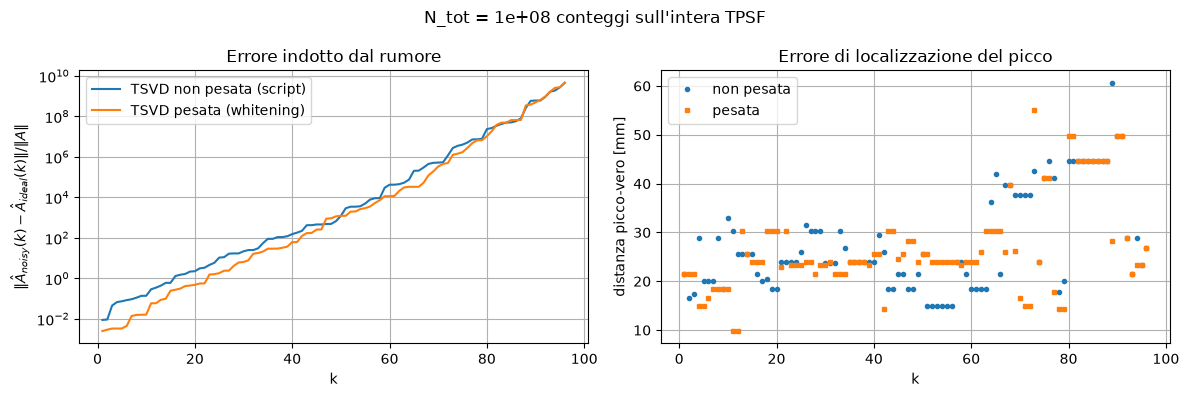

In [5]:
def simulate(N_tot_TPSF, rng):
    # conteggi attesi: frazione della TPSF intera che cade in ciascun gate
    frac_g = np.array([Phi0_int[d]/(phi0_semi(d).sum()*dt) for d in range(N_det)])
    lam0 = N_tot_TPSF*frac_g
    n0 = rng.poisson(lam0).astype(float); npert = rng.poisson(np.clip(lam0*(1 + M_ideal), 0, None)).astype(float)
    M_t = npert/(n0 + 1) - 1                                    # stimatore quasi non distorto
    sig = np.sqrt((npert + 1)/(n0 + 1)**2 + (npert + 1)**2/(n0 + 1)**3)  # sigma stimata dai dati
    return M_t.ravel(), sig.ravel()

U, s, Vt = np.linalg.svd(W, full_matrices=False)
def tsvd(Uu, ss, VV, m, k):
    return VV[:k].T @ ((Uu[:, :k].T @ m)/ss[:k])

rng = np.random.default_rng(1)
N_tot_TPSF = 1e8
M_n, sig = simulate(N_tot_TPSF, rng)
Ww = W/sig[:, None]; Uw, sw, Vtw = np.linalg.svd(Ww, full_matrices=False)
k_vals = np.arange(1, s.size + 1)

err_raw = [np.linalg.norm(tsvd(U, s, Vt, M_n, k) - tsvd(U, s, Vt, M_ideal.ravel(), k)) for k in k_vals]
err_wht = [np.linalg.norm(tsvd(Uw, sw, Vtw, M_n/sig, k) - tsvd(Uw, sw, Vtw, M_ideal.ravel()/sig, k)) for k in k_vals]
loc_raw = [np.linalg.norm(r_V[np.argmax(tsvd(U, s, Vt, M_n, k))] - [xp, yp, zp]) for k in k_vals]
loc_wht = [np.linalg.norm(r_V[np.argmax(tsvd(Uw, sw, Vtw, M_n/sig, k))] - [xp, yp, zp]) for k in k_vals]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(k_vals, np.array(err_raw)/np.linalg.norm(A), label='TSVD non pesata (script)')
ax[0].semilogy(k_vals, np.array(err_wht)/np.linalg.norm(A), label='TSVD pesata (whitening)')
ax[0].set(xlabel='k', ylabel=r'$\|\hat A_{noisy}(k)-\hat A_{ideal}(k)\|/\|A\|$', title='Errore indotto dal rumore')
ax[0].legend(); ax[0].grid()
ax[1].plot(k_vals, loc_raw, 'o', ms=3, label='non pesata'); ax[1].plot(k_vals, loc_wht, 's', ms=3, label='pesata')
ax[1].set(xlabel='k', ylabel='distanza picco-vero [mm]', title='Errore di localizzazione del picco'); ax[1].legend(); ax[1].grid()
fig.suptitle(f'N_tot = {N_tot_TPSF:.0e} conteggi sull\'intera TPSF'); plt.tight_layout(); plt.show()

**Lettura del grafico.** A parità di $k$ il whitening riduce l'errore indotto dal rumore di circa
un ordine di grandezza nei primi modi (le basi SVD sono diverse, quindi il confronto a pari $k$ è
indicativo, non rigoroso). La localizzazione resta però scadente per entrambi i metodi: anche con
$10^8$ conteggi sulla TPSF lo SNR complessivo è ~2.5 (§6.1), e una sola inclusione da 64 mm$^3$ a
18 mm con $\delta\mu_a=0.01$ mm$^{-1}$ è semplicemente al limite di rivelabilità di questa geometria.

### 6.1 Quanti fotoni servono?
Lo SNR complessivo scala come $\sqrt{N_{tot}}$. Si stima il budget per cui i dati contengono
informazione utile sull'inclusione:

In [6]:
frac_g = np.array([Phi0_int[d]/(phi0_semi(d).sum()*dt) for d in range(N_det)])
for Nt in [1e6, 1e7, 1e8, 1e9]:
    lam0 = Nt*frac_g
    snr = np.sqrt((M_ideal**2*lam0/((1 + M_ideal)*(2 + M_ideal))).sum())
    print(f"N_tot(TPSF) = {Nt:.0e}:  conteggi ultimo gate D1 = {lam0[0,-1]:8.1f}   SNR complessivo = {snr:6.2f}")

N_tot(TPSF) = 1e+06:  conteggi ultimo gate D1 =     10.2   SNR complessivo =   0.24
N_tot(TPSF) = 1e+07:  conteggi ultimo gate D1 =    102.1   SNR complessivo =   0.77
N_tot(TPSF) = 1e+08:  conteggi ultimo gate D1 =   1020.6   SNR complessivo =   2.45
N_tot(TPSF) = 1e+09:  conteggi ultimo gate D1 =  10205.7   SNR complessivo =   7.74


## 7. Riepilogo

| # | Tipo | Problema | Correzione |
|---|------|----------|-----------|
| 1 | concettuale | $N_{tot}$ distribuito solo sui 12 gate (2–3 % della TPSF); commento "vicino al picco" errato | normalizzare sull'intera TPSF |
| 2 | concettuale | SNR per gate ≈ 0.1–0.3: ricostruzione dominata dal rumore | aumentare $N_{tot}$, $\delta\mu_a V$ o ridurre profondità; dichiararlo |
| 3 | metodologico | TSVD non pesata con rumore eteroschedastico | whitening $\Sigma^{-1/2}$ |
| 4 | statistico | stimatore $(N_p-N_0)/N_0$ con bias $\approx 1/\lambda_0$ | $N_p/(N_0+1)-1$ |
| 5 | concettuale | gate precoci descritti come sensibili alla profondità | solo i tardivi |
| 6 | metodologico | inverse crime; metrica $\|\hat A-A\|$ poco informativa | modello diverso per i dati; metriche di localizzazione |
| 7 | codice | variabili inutilizzate, titolo hard-coded, API random legacy | pulizia |

Formula chiave: $\;\sigma_M^2\approx\dfrac{(1+M)(2+M)}{\lambda^{(0)}}\approx\dfrac{2}{\lambda^{(0)}}$,
$\;\mathrm{SNR}\approx|M|\sqrt{\lambda^{(0)}/2}$.